In [19]:
from google.colab import files
uploaded = files.upload()

Saving solar_severity_with_baseline.csv to solar_severity_with_baseline (1).csv


Fault counts before balancing:
f_nv
4    188473
3      6024
1      5999
Name: count, dtype: int64

Dataset Balanced to 5999 samples per class.
New Class Distribution:
f_nv
1    5999
3    5999
4    5999
Name: count, dtype: int64


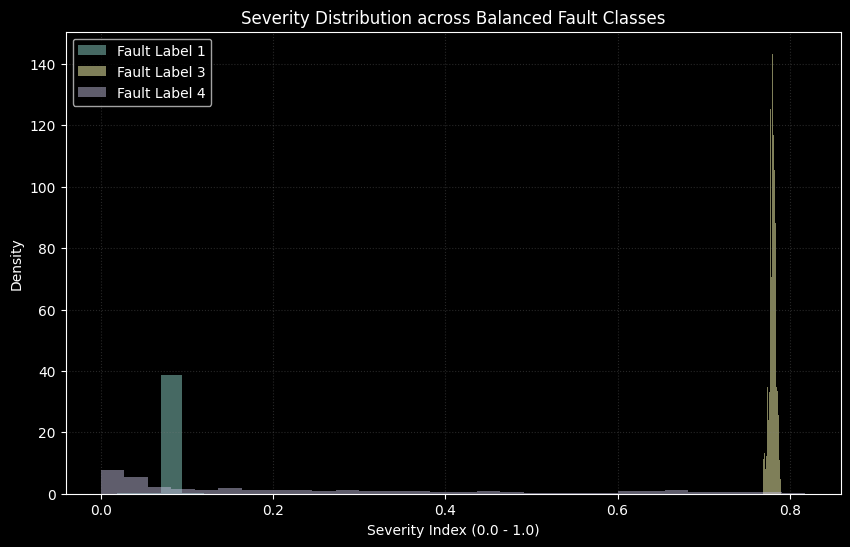

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD THE PROCESSED DATA
# This code assumes you have 'solar_severity_with_baseline.csv' in your environment
df = pd.read_csv('solar_severity_with_baseline.csv')

# 2. REMOVE HEALTHY ROWS
# We focus only on labels 1 (Soiling), 3 (String Fault), and 4 (Hardware Failure)
df_faults = df[~df['f_nv'].isin([0, 2])].copy()

print("Fault counts before balancing:")
print(df_faults['f_nv'].value_counts())

# 3. BALANCE THE DATASET (Undersampling)
# We find the smallest class size to ensure equal representation
min_samples = df_faults['f_nv'].value_counts().min()

# Randomly sample from each group
df_balanced = df_faults.groupby('f_nv').sample(n=min_samples, random_state=42)

print(f"\nDataset Balanced to {min_samples} samples per class.")
print("New Class Distribution:")
print(df_balanced['f_nv'].value_counts())

# 4. SAVE THE BALANCED DATASET
df_balanced.to_csv('balanced_fault_dataset.csv', index=False)

# 5. VISUALIZATION (Dark Theme)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plotting the Severity Distribution for balanced classes
for fault_label in sorted(df_balanced['f_nv'].unique()):
    subset = df_balanced[df_balanced['f_nv'] == fault_label]
    plt.hist(subset['severity_index'], bins=30, alpha=0.5,
             label=f'Fault Label {fault_label}', density=True)

plt.title('Severity Distribution across Balanced Fault Classes', color='white')
plt.xlabel('Severity Index (0.0 - 1.0)', color='white')
plt.ylabel('Density', color='white')
plt.legend()
plt.grid(color='gray', linestyle=':', alpha=0.3)
plt.show()

# 6. DOWNLOAD COMMAND
from google.colab import files
files.download('balanced_fault_dataset.csv')

In [17]:
print(df[df['f_nv']==0].describe())

               vdc1          vdc2          idc1          idc2           irr  \
count  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06  1.162931e+06   
mean   1.092099e+02  1.089400e+02  1.866807e+00  1.768347e+00  2.048314e+02   
std    1.316979e+02  1.315317e+02  3.145143e+00  3.076162e+00  3.470097e+02   
min    3.799000e-01  3.164000e-01  4.180000e-02  4.600000e-03 -3.810000e-02   
25%    7.980000e-01  7.724000e-01  6.630000e-02  1.020000e-02  1.263300e+00   
50%    1.906900e+00  2.180600e+00  1.099000e-01  4.030000e-02  1.441900e+00   
75%    2.668840e+02  2.671050e+02  1.104000e+00  1.031550e+00  2.602400e+02   
max    3.639740e+02  3.687490e+02  9.654900e+00  9.433900e+00  1.085920e+03   

                pvt       f_nv        p_meas        p_theo     delta_str  \
count  1.162931e+06  1162931.0  1.162931e+06  1.162931e+06  1.162931e+06   
mean   2.081519e+01        0.0  9.622015e+02  9.286719e+02  4.112873e-01   
std    1.383588e+01        0.0  1.679670e+03  1.561275e+03  